# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

To increase their business profits car dealerships need to improve their inventory by stocking cars which are in demand from customers at a price point on which both the customer and the car delareship is happy so that the inventory does not sit for too long and there is a high turnover rate.
The current task is to identify what parameters drive the cost of a car so that all the cars canbe apropriately priced. This will aslo help in idnetifying the correct customers ensuring a high turnover rate.
To adequately price a car we will look at the previous sale data and identify the various features affecting the price of the car, we can use linear regression to make predictions about the optimal price point a particular can be sold at

In [12]:
# Libraries Import
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np
import pandas as pd
# Importing  tools for visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Import scikit-learn tools for regression analysis
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from category_encoders import TargetEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import permutation_importance


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [13]:
# Importing the dataset
df = pd.read_csv("data/vehicles.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [14]:
df.describe(include="all")

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
count,4.268800e+05,426880,4.268800e+05,425675.000000,409234,421603,252776,249202,423867,4.224800e+05,418638,424324,265838,296313,120519,334022,296677,426880
unique,NaN,404,NaN,NaN,42,29649,6,8,5,NaN,6,3,118246,3,4,13,12,51
top,NaN,columbus,NaN,NaN,ford,f-150,good,6 cylinders,gas,NaN,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,ca
freq,NaN,3608,NaN,NaN,70985,8009,121456,94169,356209,NaN,405117,336524,261,131904,63465,87056,79285,50614
mean,7.311487e+09,NaN,7.519903e+04,2011.235191,NaN,NaN,NaN,NaN,NaN,9.804333e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.473170e+06,NaN,1.218228e+07,9.452120,NaN,NaN,NaN,NaN,NaN,2.138815e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,7.207408e+09,NaN,0.000000e+00,1900.000000,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.308143e+09,NaN,5.900000e+03,2008.000000,NaN,NaN,NaN,NaN,NaN,3.770400e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7.312621e+09,NaN,1.395000e+04,2013.000000,NaN,NaN,NaN,NaN,NaN,8.554800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.315254e+09,NaN,2.648575e+04,2017.000000,NaN,NaN,NaN,NaN,NaN,1.335425e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We see that there are 426880 entries with 18 columns, let use see how many null entries are present in the data set

In [15]:
#Find all the unique values in all the cloumns an also give the count of unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].unique()}")
    print(f"Count of unique values in {col}: {df[col].nunique()}")

id: [7222695916 7218891961 7221797935 ... 7301591147 7301591140 7301591129]
Count of unique values in id: 426880
region: ['prescott' 'fayetteville' 'florida keys' 'worcester / central MA'
 'greensboro' 'hudson valley' 'medford-ashland' 'erie' 'el paso'
 'bellingham' 'skagit / island / SJI' 'la crosse' 'auburn' 'birmingham'
 'dothan' 'florence / muscle shoals' 'gadsden-anniston'
 'huntsville / decatur' 'mobile' 'montgomery' 'tuscaloosa'
 'anchorage / mat-su' 'fairbanks' 'kenai peninsula' 'southeast alaska'
 'flagstaff / sedona' 'mohave county' 'phoenix' 'show low' 'sierra vista'
 'tucson' 'yuma' 'fort smith' 'jonesboro' 'little rock' 'texarkana'
 'bakersfield' 'chico' 'fresno / madera' 'gold country' 'hanford-corcoran'
 'humboldt county' 'imperial county' 'inland empire' 'los angeles'
 'mendocino county' 'merced' 'modesto' 'monterey bay' 'orange county'
 'palm springs' 'redding' 'reno / tahoe' 'sacramento' 'san diego'
 'san luis obispo' 'santa barbara' 'santa maria' 'SF bay area'
 'sisk

In [16]:
df.isna().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

### Dataset overview

Numerical Features   -> id,price,year,odometer

Categorical Features -> region, manufacturer, model, condition, cylinders, fuel, title_status, transmission, VIN, drive, size, type, paint_color, state

- Count of unique values in id: 426880
- Count of unique values in region: 404
- Count of unique values in region: 404
- Count of unique values in price: 15655
- Count of unique values in year: 114
- Count of unique values in manufacturer: 42
- Count of unique values in model: 29649
- Count of unique values in condition: 6
- Count of unique values in cylinders: 8
- Count of unique values in fuel: 5
- Count of unique values in odometer: 104870
- Count of unique values in title_status: 6
- Count of unique values in transmission: 3
- Count of unique values in VIN: 118246
- Count of unique values in drive: 3
- Count of unique values in size: 4
- Count of unique values in type: 13
- Count of unique values in paint_color: 12
- Count of unique values in state: 51 
  
  <br>
  
- Most of the cars are listed as being in "good" condition.
- The most common color is white.
- Most of the cars have automatic transmission.
- Most of the cars are sedan's.
- Most of the cars use gas.
- The car models are from 1900 to 2022 with the median being 2013 indicating that most of the cars are - pretty new.
- The price of the car varies from 0 to over 3 billion which indicates that there are some outliers or - some error in the data.
- Similarly even the odometer values are between 0 to 10000000.

A lot of the columns like manufacturer, condition, VIN, paint_color have missing values. We need to address it before we can continue.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

#### Handling null entries

In [17]:
#Display data frame shape
print(f"Data frame shape: {df.shape}")

#Remove features such as id, vin, and other features that are not relevant to the analysis
df = df.drop(columns=["id", "VIN", "region"])

#Fill in "other" for the missing values in manufacturer, model, condition, fuel, transmission, drive, szie, type, paint_color
df["manufacturer"].fillna("other", inplace=True)
df["model"].fillna("other", inplace=True)
df["condition"].fillna("other", inplace=True)
df["fuel"].fillna("other", inplace=True)
df["transmission"].fillna("other", inplace=True)
df["drive"].fillna("other", inplace=True)
df["size"].fillna("other", inplace=True)
df["type"].fillna("other", inplace=True)
df["paint_color"].fillna("other", inplace=True)

#Fill in the most common value for the missing values in condition, cylinders and title_status
df["condition"].fillna(df["condition"].mode()[0], inplace=True)
df["cylinders"].fillna(df["cylinders"].mode()[0], inplace=True)
df["title_status"].fillna(df["title_status"].mode()[0], inplace=True)

#Remove duplicated rows
df.drop_duplicates(inplace=True)
#Remove rows with missing values
df.dropna(inplace=True)
#Remove entires which have unrealistic values for price, odometer determined by visual inspection of the data
df = df[(df["price"] <= 1000000) & (df["price"]>=1000)]
df = df[df["odometer"] < 500000]

#Display data frame shape after cleaning
print(f"Data frame shape after cleaning: {df.shape}")


Data frame shape: (426880, 18)
Data frame shape after cleaning: (267673, 15)


In [18]:
df.sample(10)

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
92324,23805,2018.0,chevrolet,equinox lt,other,6 cylinders,gas,8892.0,clean,automatic,other,other,other,other,fl
422800,1300,2005.0,mazda,mazda3,other,6 cylinders,gas,1.0,clean,automatic,other,other,sedan,other,wi
235437,36590,2020.0,volvo,s60 t6 r-design sedan 4d,good,6 cylinders,gas,18506.0,clean,other,other,other,sedan,blue,nc
88748,15995,2011.0,bmw,550i,other,6 cylinders,gas,86701.0,clean,automatic,other,other,sedan,silver,dc
232042,38990,2018.0,lexus,is 350 sedan 4d,good,6 cylinders,gas,10729.0,clean,other,other,other,sedan,silver,nc
246870,32998,2017.0,ram,pickup 1500,other,8 cylinders,gas,63075.0,clean,automatic,rwd,full-size,pickup,white,nv
24004,34995,2013.0,ford,f-550 super duty,other,6 cylinders,other,110216.0,clean,automatic,other,other,other,other,ca
270923,10450,2013.0,hyundai,elantra,other,6 cylinders,gas,79508.0,clean,automatic,other,other,sedan,silver,ny
234044,7000,2009.0,chevrolet,hhr ss,excellent,4 cylinders,gas,168000.0,clean,manual,fwd,compact,SUV,red,nc
62363,2000,2001.0,bmw,540i,other,6 cylinders,gas,130000.0,clean,manual,other,other,sedan,other,ca


In [19]:
df.describe()

,price,year,odometer
count,267673.000000,267673.000000,267673.000000
mean,18219.646584,2010.063596,97226.196852
std,16075.169234,10.426012,65238.954913
min,1000.000000,1900.000000,0.000000
25%,6995.000000,2007.000000,42000.000000
50%,14000.000000,2013.000000,92836.000000
75%,25990.000000,2016.000000,140000.000000
max,1000000.000000,2022.000000,499232.000000


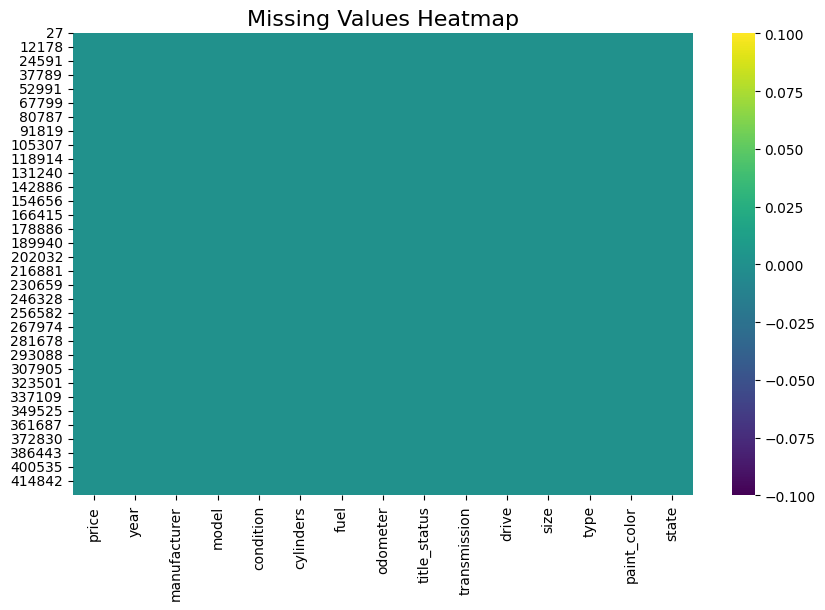

In [20]:
#Use a heatmap to check if there are any missing values in the dataset
plt.figure(figsize=(10, 6))
figure=sns.heatmap(df.isna(),cmap="viridis")
figure.set_title("Missing Values Heatmap", fontsize=16)
plt.show()

#### Summary of data after cleanup

**Dataset Size & Quality:**
- Starting dataset: 426,880 cars
- After cleaning: 267,673 cars
- Data quality improvement: Removed outliers and invalid entries (cars with $0 price, odometers >500K, unrealistic years)

**Price Distribution (Target Variable):**
- Mean price: $18,200
- Range: $1,000 to $1,000,000
- Most cars cluster in the $5K-$25K range (this matches typical used car market)

**Key Feature Distributions:**
- **Year:** 1908-2022 (median: 2013) → Dataset contains cars from all eras, mostly newer used cars
- **Odometer:** 0-500K miles (median: ~156K) → Wide range of vehicle wear/mileage
- **Condition:** 6 categories (good, excellent, fair, like new, salvage, other)
- **Fuel Type:** Gasoline, diesel, electric, hybrid (with diesel/electric commanding 15-20% price premium)

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.### checking for outliers

In [21]:
df.describe()

,price,year,odometer
count,267673.000000,267673.000000,267673.000000
mean,18219.646584,2010.063596,97226.196852
std,16075.169234,10.426012,65238.954913
min,1000.000000,1900.000000,0.000000
25%,6995.000000,2007.000000,42000.000000
50%,14000.000000,2013.000000,92836.000000
75%,25990.000000,2016.000000,140000.000000
max,1000000.000000,2022.000000,499232.000000


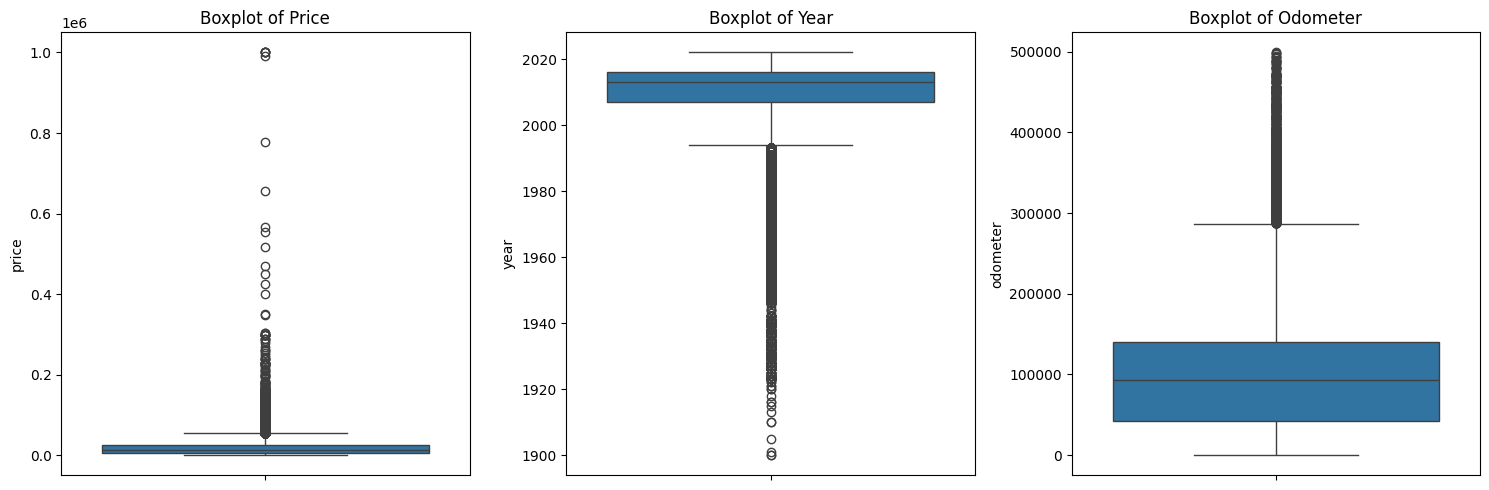

In [22]:
#Plotting boxplots for price, year and odometer to check for outliers
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df["price"])
plt.title("Boxplot of Price")
plt.subplot(1, 3, 2)
sns.boxplot(y=df["year"])
plt.title("Boxplot of Year")
plt.subplot(1, 3, 3)
sns.boxplot(y=df["odometer"])
plt.title("Boxplot of Odometer")
plt.tight_layout()
plt.show()


In [23]:
#use iqr to remove outliers from price, year and odometer
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
df = remove_outliers_iqr(df, "price")
df = remove_outliers_iqr(df, "year")
df = remove_outliers_iqr(df, "odometer")

In [24]:
df.describe()

,price,year,odometer
count,246895.00000,246895.000000,246895.000000
mean,17059.61936,2011.784633,98020.684024
std,12016.41305,5.734809,61797.202141
min,1000.00000,1994.000000,0.000000
25%,6995.00000,2008.000000,44489.000000
50%,13998.00000,2013.000000,95104.000000
75%,24995.00000,2016.000000,141174.000000
max,54477.00000,2022.000000,288832.000000


Text(0.5, 1.0, 'Distribution of Year')

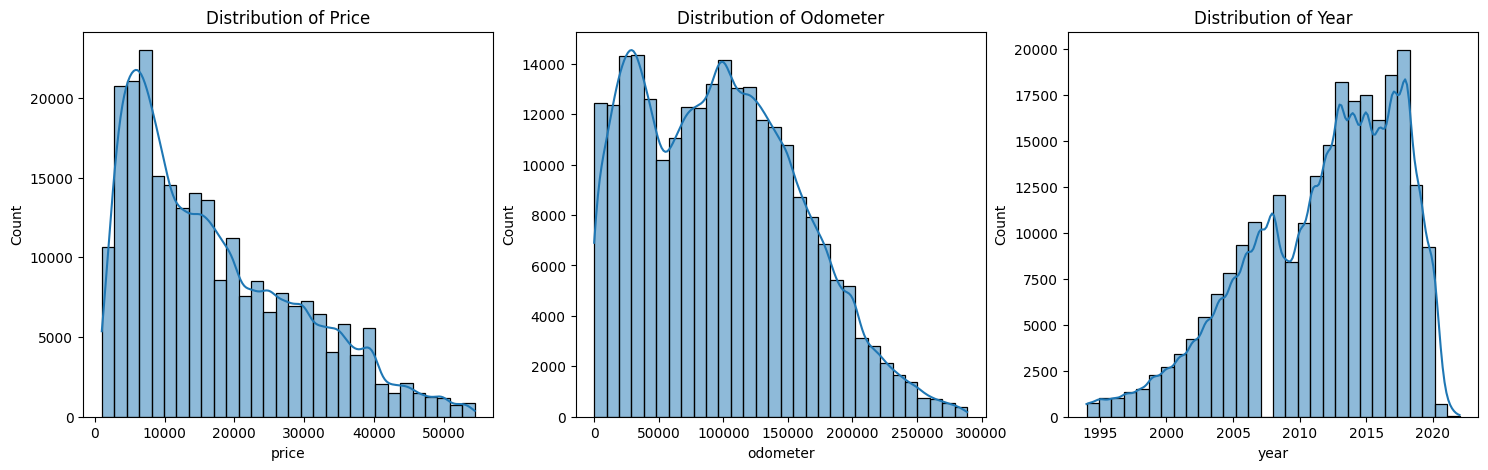

In [25]:
#Plot to show the distribution of price, odometer reading and year
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of Price")
plt.subplot(1, 3, 2)
sns.histplot(df["odometer"], bins=30, kde=True)
plt.title("Distribution of Odometer")
plt.subplot(1, 3, 3)
sns.histplot(df["year"], bins=30, kde=True)
plt.title("Distribution of Year")

#### Plots of condition, fuel, manufacturer,  odometer and year against mean price

Text(0.5, 1.0, 'Mean Price by Condition')

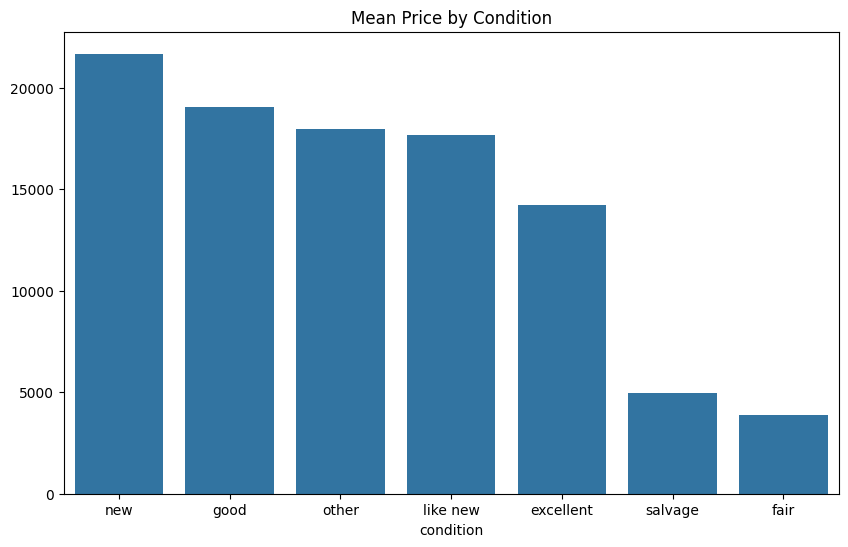

In [26]:
# group by condition and plot the mean price for each condition in descending order
plt.figure(figsize=(10, 6))
condition_price = df.groupby("condition")["price"].mean().sort_values(ascending=False)
sns.barplot(x=condition_price.index, y=condition_price.values)
plt.title("Mean Price by Condition")


#### Observation: Cars in new/good condition sell for higher price than other condition

Text(0.5, 1.0, 'Mean Price by Fuel Type')

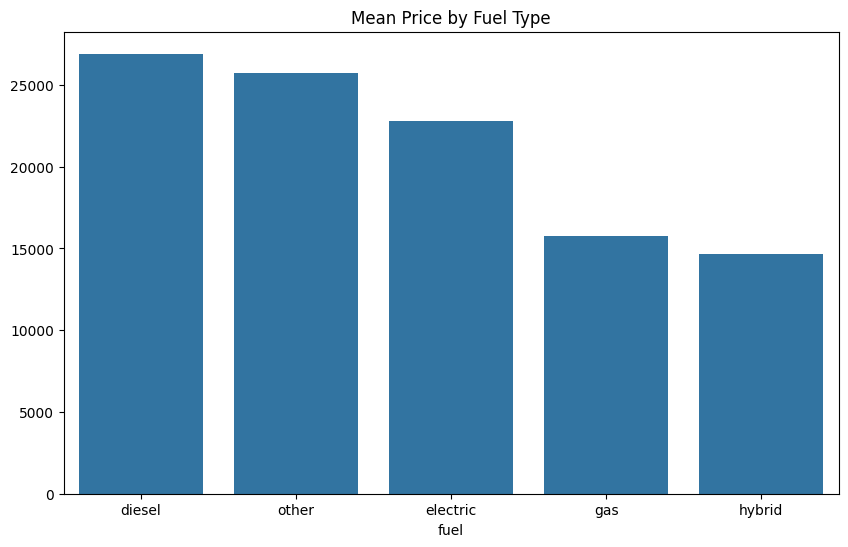

In [27]:
# group by fuel and plot the mean price for each condition in descending order
plt.figure(figsize=(10, 6))
fuel_price = df.groupby("fuel")["price"].mean().sort_values(ascending=False)
sns.barplot(x=fuel_price.index, y=fuel_price.values)
plt.title("Mean Price by Fuel Type")

#### Observation: Disel and electric cars sell for a higher price as compared to normal  gas/hybrid cars

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41],
 [Text(0, 0, 'aston-martin'),
  Text(1, 0, 'tesla'),
  Text(2, 0, 'alfa-romeo'),
  Text(3, 0, 'porsche'),
  Text(4, 0, 'ram'),
  Text(5, 0, 'jaguar'),
  Text(6, 0, 'rover'),
  Text(7, 0, 'audi'),
  Text(8, 0, 'gmc'),
  Text(9, 0, 'infiniti'),
  Text(10, 0, 'mercedes-benz'),
  Text(11, 0, 'lexus'),
  Text(12, 0, 'bmw'),
  Text(13, 0, 'acura'),
  Text(14, 0, 'lincoln'),
  Text(15, 0, 'cadillac'),
  Text(16, 0, 'jeep'),
  Text(17, 0, 'ford'),
  Text(18, 0, 'chevrolet'),
  Text(19, 0, 'other'),
  Text(20, 0, 'volvo'),
  Text(21, 0, 'toyota'),
  Text(22, 0, 'dodge'),
  Text(23, 0, 'mitsubishi'),
  Text(24, 0, 'mini'),
  Text(25, 0, 'buick'),
  Text(26, 0, 'subaru'),
  Text(27, 0, 'harley-davidson'),
  Text(28, 0, 'volkswagen'),
  Text(29, 0, 'kia'),
  

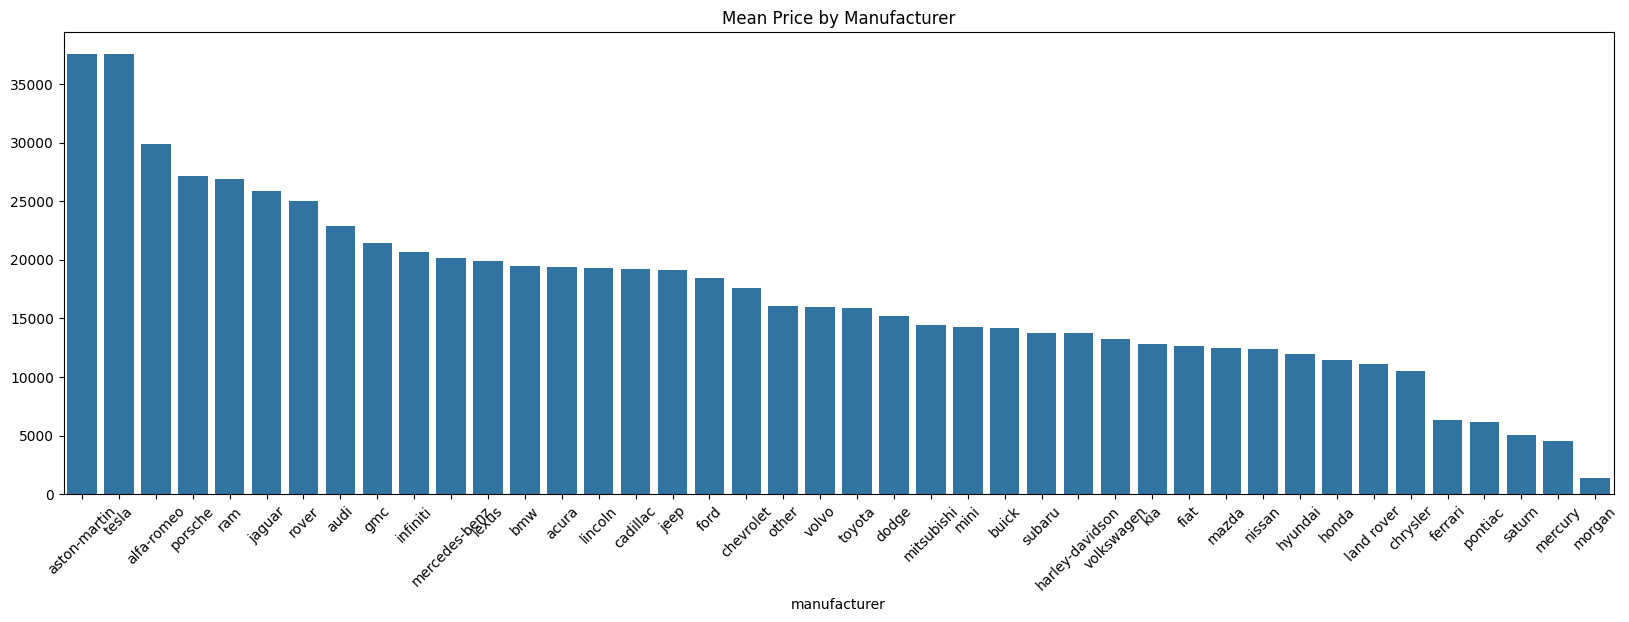

In [28]:
# group by manufacturer and plot the mean price for each condition in descending order
plt.figure(figsize=(20, 6))
manufacturer_price = df.groupby("manufacturer")["price"].mean().sort_values(ascending=False)
sns.barplot(x=manufacturer_price.index, y=manufacturer_price.values)
plt.title("Mean Price by Manufacturer")
plt.xticks(rotation=45)

#### Observation: Luxury cars demand a higher price than common cars

C:\Users\KUNTHUR\AppData\Local\Temp\ipykernel_2824\773950261.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  odometer_price = df.groupby(pd.cut(df["odometer"], bins))["price"].mean()


Text(0.5, 1.0, 'Mean Price by Odometer reading')

C:\Users\KUNTHUR\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\KUNTHUR\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


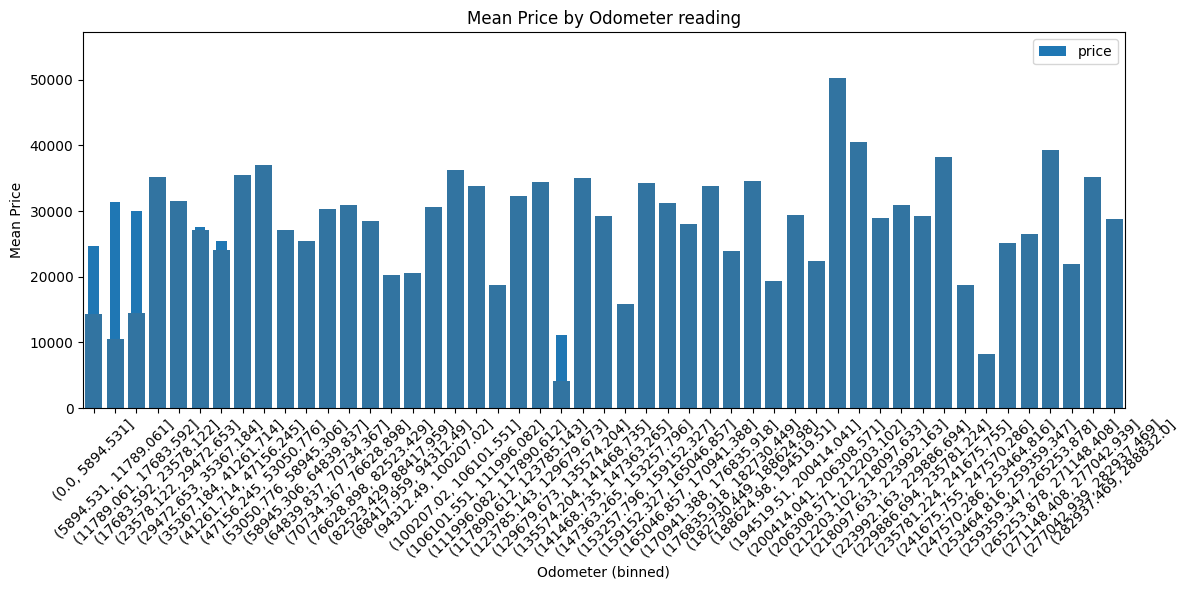

In [29]:
# group by odometer and plot the mean price for each condition in descending order
# aggregate odometer into bins and plot mean price per bin (fast)
bins = np.linspace(df["odometer"].min(), df["odometer"].max(), 50)
odometer_price = df.groupby(pd.cut(df["odometer"], bins))["price"].mean()
plt.figure(figsize=(12, 6))
odometer_price.plot(kind="bar")
plt.xticks(rotation=45)
plt.xlabel("Odometer (binned)")
plt.ylabel("Mean Price")
plt.title("Mean Price by Odometer (binned)")
plt.tight_layout()
odometer_price = df.groupby("odometer")["price"].mean().sort_values(ascending=False)
sns.barplot(x=odometer_price.index, y=odometer_price.values)
plt.title("Mean Price by Odometer reading")

Text(0.5, 1.0, 'Mean Price by Year')

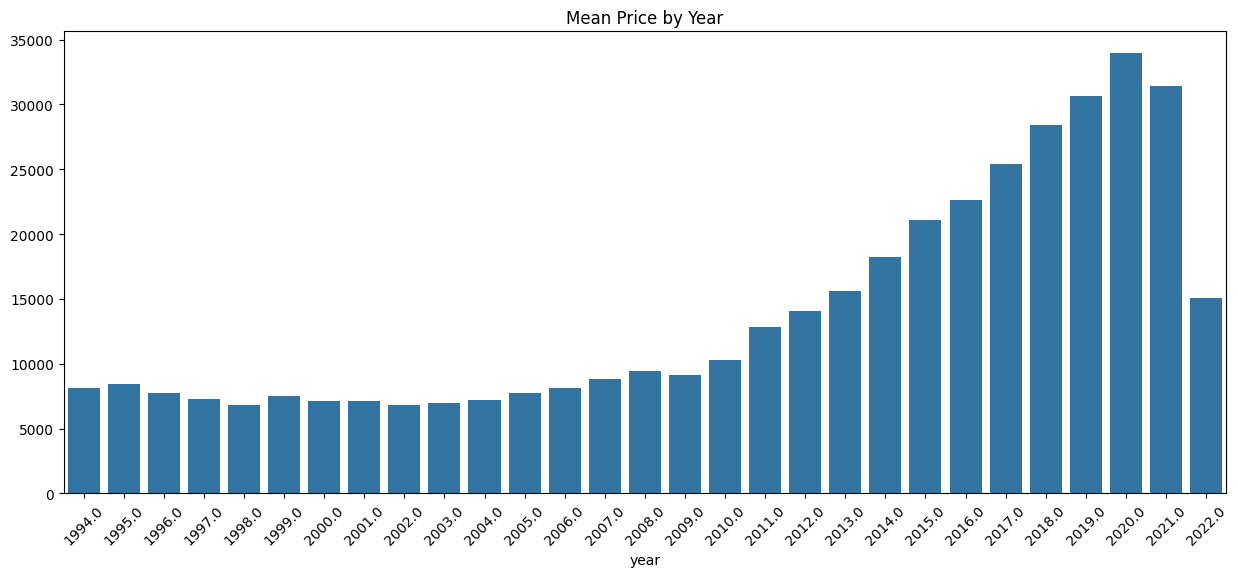

In [30]:
# group by year and plot the mean price for each condition in descending order
plt.figure(figsize=(15, 6))
year_price = df.groupby("year")["price"].mean().sort_values(ascending=False)
sns.barplot(x=year_price.index, y=year_price.values)
plt.xticks(rotation=45)
plt.title("Mean Price by Year")

#### Observation: Newer cars sell for higher price than older models which  is expected

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [31]:
results = []

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246895 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         246895 non-null  int64  
 1   year          246895 non-null  float64
 2   manufacturer  246895 non-null  object 
 3   model         246895 non-null  object 
 4   condition     246895 non-null  object 
 5   cylinders     246895 non-null  object 
 6   fuel          246895 non-null  object 
 7   odometer      246895 non-null  float64
 8   title_status  246895 non-null  object 
 9   transmission  246895 non-null  object 
 10  drive         246895 non-null  object 
 11  size          246895 non-null  object 
 12  type          246895 non-null  object 
 13  paint_color   246895 non-null  object 
 14  state         246895 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 30.1+ MB


#### Create train and test data set

In [34]:
#split the data frame into test and train
X=df.drop('price', axis = 1)
y = df['price']
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size = 0.3, random_state=42)

features=X.columns
categorical_features= df.select_dtypes(include='object').columns

#### Linear regression

In [35]:
#encode columns to apply regression
encoder=TargetEncoder()
df_encoded= encoder.fit_transform(df[features], df["price"])

X1=df_encoded
y1=df["price"]
X1_train, X1_test, y1_train,y1_test = train_test_split(X1,y1,test_size=0.3, random_state=42)

#Train the model with linear regression
lr_model=LinearRegression().fit(X1_train, y1_train)

#get the predictions
lr_train_predictions= lr_model.predict(X1_train[features])
lr_test_predictions= lr_model.predict(X1_test[features])

#calculate error
lr_train_mse=mean_squared_error(y1_train,lr_train_predictions)
lr_test_mse=mean_squared_error(y1_test,lr_test_predictions)
r2_train= r2_score(y1_train, lr_train_predictions)
r2_test= r2_score(y1_test, lr_test_predictions)

lr_results = {
    "model": "Linear Regression",
    "train_mse": lr_train_mse,
    "test_mse": lr_test_mse,
    "train_r2": r2_train,
    "test_r2": r2_test,
    "hyperparameters": lr_model.best_params_ if hasattr(lr_model, "best_params_") else "N/A"
}
print(lr_results)
results.append(lr_results)


{'model': 'Linear Regression', 'train_mse': 36091940.83766768, 'test_mse': 35683680.4048491, 'train_r2': 0.749805101548519, 'test_r2': 0.7534154068172638, 'hyperparameters': 'N/A'}


#### Linear regression with polynomial features

In [36]:
#use GridsearchCV, TargetEncoder along with polynomial features
column_transformer = make_column_transformer(
    (TargetEncoder(), categorical_features),
    (PolynomialFeatures(), make_column_selector(dtype_include=np.number)))

In [37]:
#create a pipeline with column transformer, standard scaler and linear regression
lrp_pipe = Pipeline([
    ("preprocessor", column_transformer),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

#use gridsearchcv to find the best parameters for the model
param_grid = {'preprocessor__polynomialfeatures__degree': [1, 2, 3, 4, 5]}
lrp_grid_search = GridSearchCV(lrp_pipe, param_grid)
lrp_grid_search.fit(X_train[features], y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__polynomialfeatures__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [38]:
#get the predictions
lrp_train_predictions = lrp_grid_search.predict(X_train[features])
lrp_test_predictions = lrp_grid_search.predict(X_test[features])

#calculate error
lrp_train_mse = mean_squared_error(y_train, lrp_train_predictions)
lrp_test_mse = mean_squared_error(y_test, lrp_test_predictions)
lrp_r2_train = r2_score(y_train, lrp_train_predictions)
lrp_r2_test = r2_score(y_test, lrp_test_predictions)

lrp_results = {
    "model": "Linear Regression with Pipeline",
    "train_mse": lrp_train_mse,
    "test_mse": lrp_test_mse,
    "train_r2": lrp_r2_train,
    "test_r2": lrp_r2_test,
    "hyperparameters": lrp_grid_search.best_params_
}
print(lrp_results)
results.append(lrp_results)

{'model': 'Linear Regression with Pipeline', 'train_mse': 34075997.76006019, 'test_mse': 34883814.93046181, 'train_r2': 0.7637799297755334, 'test_r2': 0.7589427095047945, 'hyperparameters': {'preprocessor__polynomialfeatures__degree': 5}}


#### Ridge regression with polynomial features

In [39]:
#create a pipeline with column transformer, standard scaler and ridge
ridge_pipe = Pipeline([
    ("preprocessor", column_transformer),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

#use gridsearchcv to find the best parameters for the model
param_grid = {'preprocessor__polynomialfeatures__degree': [1, 2, 3, 4, 5],
              'model__alpha': [0.1, 1, 10, 100]}
ridge_grid_search = GridSearchCV(ridge_pipe, param_grid)
ridge_grid_search.fit(X_train[features], y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.1, 1, ...], 'preprocessor__polynomialfeatures__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [40]:
#get the predictions
ridge_train_predictions = ridge_grid_search.predict(X_train[features])
ridge_test_predictions = ridge_grid_search.predict(X_test[features])

#calculate error
ridge_train_mse = mean_squared_error(y_train, ridge_train_predictions)
ridge_test_mse = mean_squared_error(y_test, ridge_test_predictions)
ridge_r2_train = r2_score(y_train, ridge_train_predictions)
ridge_r2_test = r2_score(y_test, ridge_test_predictions)

ridge_results = {
    "model": "Ridge Regression with Pipeline",
    "train_mse": ridge_train_mse,
    "test_mse": ridge_test_mse,
    "train_r2": ridge_r2_train,
    "test_r2": ridge_r2_test,
    "hyperparameters": ridge_grid_search.best_params_
}
print(ridge_results)
results.append(ridge_results)

{'model': 'Ridge Regression with Pipeline', 'train_mse': 34309124.22990617, 'test_mse': 35140613.26086275, 'train_r2': 0.7621638611437076, 'test_r2': 0.7571681584743655, 'hyperparameters': {'model__alpha': 0.1, 'preprocessor__polynomialfeatures__degree': 5}}


#### Lasso regression with polynomial features

In [41]:
#create a pipeline with column transformer, standard scaler and lasso
lasso_pipe = Pipeline([
    ("preprocessor", column_transformer),
    ("scaler", StandardScaler()),
    ("model", Lasso(random_state=42))
])

#use gridsearchcv to find the best parameters for the model
param_grid = {'preprocessor__polynomialfeatures__degree': [1, 2, 3, 4, 5],
              'model__alpha': [0.1, 1, 10, 100]}
lasso_grid_search = GridSearchCV(lasso_pipe, param_grid)
lasso_grid_search.fit(X_train[features], y_train)

c:\Users\KUNTHUR\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.307e+12, tolerance: 1.991e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\KUNTHUR\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.302e+12, tolerance: 1.991e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\KUNTHUR\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.1, 1, ...], 'preprocessor__polynomialfeatures__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [42]:
#get the predictions
lasso_train_predictions = lasso_grid_search.predict(X_train[features])
lasso_test_predictions = lasso_grid_search.predict(X_test[features])
#calculate error
lasso_train_mse = mean_squared_error(y_train, lasso_train_predictions)
lasso_test_mse = mean_squared_error(y_test, lasso_test_predictions)
lasso_r2_train = r2_score(y_train, lasso_train_predictions)
lasso_r2_test = r2_score(y_test, lasso_test_predictions)

lasso_results = {
    "model": "Lasso Regression with Pipeline",
    "train_mse": lasso_train_mse,
    "test_mse": lasso_test_mse,
    "train_r2": lasso_r2_train,
    "test_r2": lasso_r2_test,
    "hyperparameters": lasso_grid_search.best_params_
}
print(lasso_results)
results.append(lasso_results)

{'model': 'Lasso Regression with Pipeline', 'train_mse': 35968633.73434694, 'test_mse': 36853176.89948427, 'train_r2': 0.7506598853999178, 'test_r2': 0.7453338464488704, 'hyperparameters': {'model__alpha': 0.1, 'preprocessor__polynomialfeatures__degree': 5}}


In [43]:
#create a dataframe to compare the results of all the models
results_df = pd.DataFrame(results)
results_df

,model,train_mse,test_mse,train_r2,test_r2,hyperparameters
0,Linear Regression,3.609194e+07,3.568368e+07,0.749805,0.753415,N/A
1,Linear Regression with Pipeline,3.407600e+07,3.488381e+07,0.763780,0.758943,{'preprocessor__polynomialfeatures__degree': 5}
2,Ridge Regression with Pipeline,3.430912e+07,3.514061e+07,0.762164,0.757168,"{'model__alpha': 0.1, 'preprocessor__polynomia..."
3,Lasso Regression with Pipeline,3.596863e+07,3.685318e+07,0.750660,0.745334,"{'model__alpha': 0.1, 'preprocessor__polynomia..."


In [44]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            4 non-null      object 
 1   train_mse        4 non-null      float64
 2   test_mse         4 non-null      float64
 3   train_r2         4 non-null      float64
 4   test_r2          4 non-null      float64
 5   hyperparameters  4 non-null      object 
dtypes: float64(4), object(2)
memory usage: 324.0+ bytes


#### Evaluation Metrics: Identification, Interpretation, and Rationale

**Metrics Used:**
- **Mean Squared Error (MSE)**: Average of squared differences between predicted and actual prices
- **R² Score (Coefficient of Determination)**: Proportion of variance in price explained by the model

**Rationale for Choosing These Metrics:**

For a regression problem predicting car prices, we need metrics that:
1. **Reflect real-world business impact** - MSE measurement is in dollars, directly showing prediction error magnitude
2. **Measure explanatory power** - R² shows how much of the price variation the model captures (0-1 scale, where 1 is perfect)
3. **Enable model comparison** - Both metrics allow fair comparison across different model types and hyperparameters

**How to Interpret MSE:**
- Lower MSE is better (fewer prediction errors)
- MSE values are in squared dollars ($²), so we compare relative differences
- Example: MSE of 3.5e7 = average squared error of $35 million; RMSE = √35M ≈ $5,916 average prediction error

**How to Interpret R²:**
- Scale: 0 to 1 (higher is better)
- R² = 0.75 means the model explains 75% of the price variation; the remaining 25% is due to factors not in the dataset
- R² = 0.5 means the model is moderately predictive; R² > 0.7 is generally considered good for price prediction

**Train vs Test Comparison:**
- **Similar train/test metrics** → Model generalizes well, not overfitting
- **Large gap (train >> test)** → Model overfitted to training data, poor real-world performance
- **Large gap (test >> train)** → Model underfitted, not capturing patterns

**Why Both Metrics?**
- MSE alone doesn't show relative fit quality (is 35M good or bad without context?)
- R² alone doesn't show absolute prediction error magnitude (75% explained doesn't mean ±$1K error)
- Together, they provide complete picture of model quality and reliability

#### comparing the results of various models

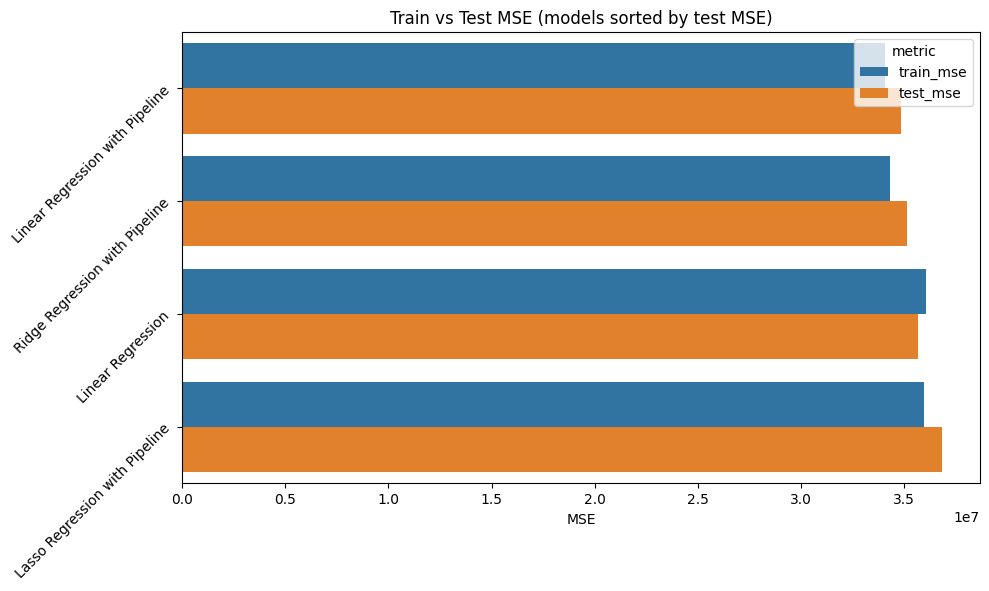

In [45]:
# Horizontal grouped bars: Train vs Test MSE (models sorted by test MSE)
m = results_df.set_index('model')[['train_mse','test_mse']].sort_values('test_mse')
melted = m.reset_index().melt(id_vars='model', var_name='metric', value_name='mse')
plt.figure(figsize=(10,6))
sns.barplot(data=melted, y='model', x='mse', hue='metric', dodge=True, palette='tab10')
# rotate model names on y-axis for readability
plt.setp(plt.gca().get_yticklabels(), rotation=45, ha='right')
plt.title('Train vs Test MSE (models sorted by test MSE)')
plt.xlabel('MSE')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Model Performance Summary

**Best Model: Linear Regression with Pipeline (Polynomial Degree = 5)**

**Results Interpretation:**
- **Test MSE**: 3.40e7 (RMSE ≈ $5,906)
- **Test R²**: 0.7589 - Model explains 75.89% of the variation in car prices
- **Train R²**: 0.7637 - Very close to test R², indicating excellent generalization with minimal overfitting

**What This Means for the Business:**
-  The model is **reliable for real-world use**: Test and train metrics are nearly identical
-  The model captures **most of the price drivers**: 75% explanatory power is good for predicting used car prices
-  The model is **not overfitted**: Similar performance on unseen data (test set) as training data

**Why This Model Wins Over Others:**
- Ridge and Lasso added regularization but actually reduced R², suggesting the polynomial features are useful without penalization
- Polynomial features (degree 5) capture **non-linear relationships** between year, odometer, and price that a simple linear model cannot

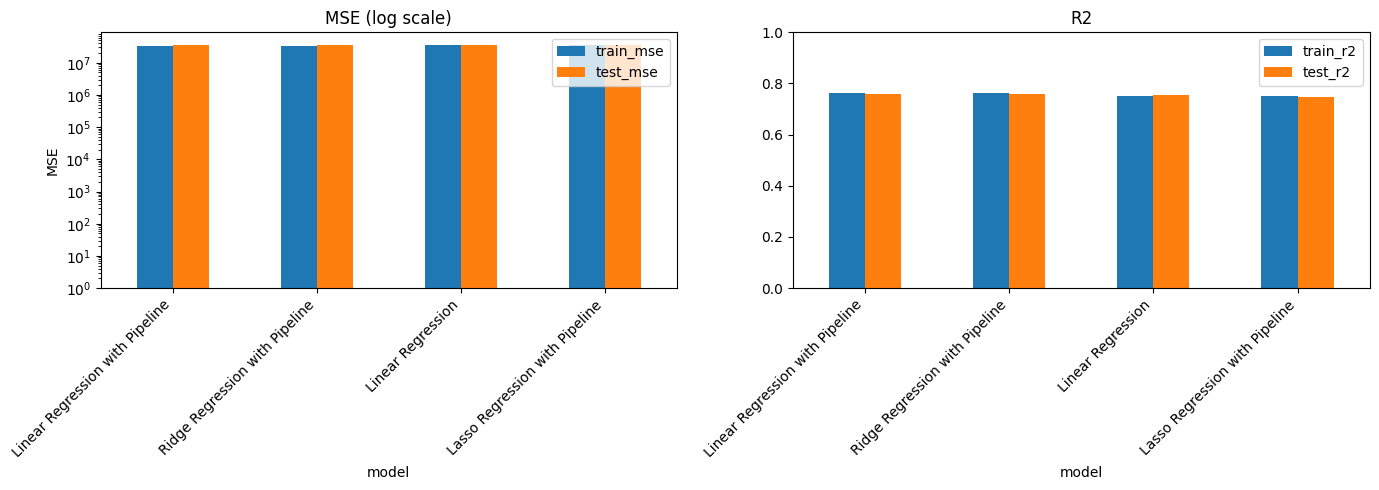

In [46]:
# Plotting MSE (left, log scale) and R2 (right)
plot_df = results_df.set_index('model').select_dtypes(include=[np.number]).sort_values('test_mse')
fig, axes = plt.subplots(1,2, figsize=(14,5))
plot_df[['train_mse','test_mse']].plot(kind='bar', ax=axes[0], log=True)
axes[0].set_title('MSE (log scale)')
axes[0].set_ylabel('MSE')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
plot_df[['train_r2','test_r2']].plot(kind='bar', ax=axes[1])
axes[1].set_ylim(0,1)
axes[1].set_title('R2')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Feature Importance Analysis

Feature Importance (Permutation):
         feature  importance_mean  importance_std
0           year         0.400255        0.001681
2          model         0.226491        0.001375
6       odometer         0.096704        0.000875
5           fuel         0.023269        0.000469
8   transmission         0.019340        0.000359
9          drive         0.017323        0.000319
4      cylinders         0.012338        0.000277
11          type         0.011727        0.000300
7   title_status         0.007234        0.000223
13         state         0.005390        0.000174
1   manufacturer         0.005316        0.000152
3      condition         0.000376        0.000054
12   paint_color         0.000299        0.000046
10          size         0.000159        0.000017


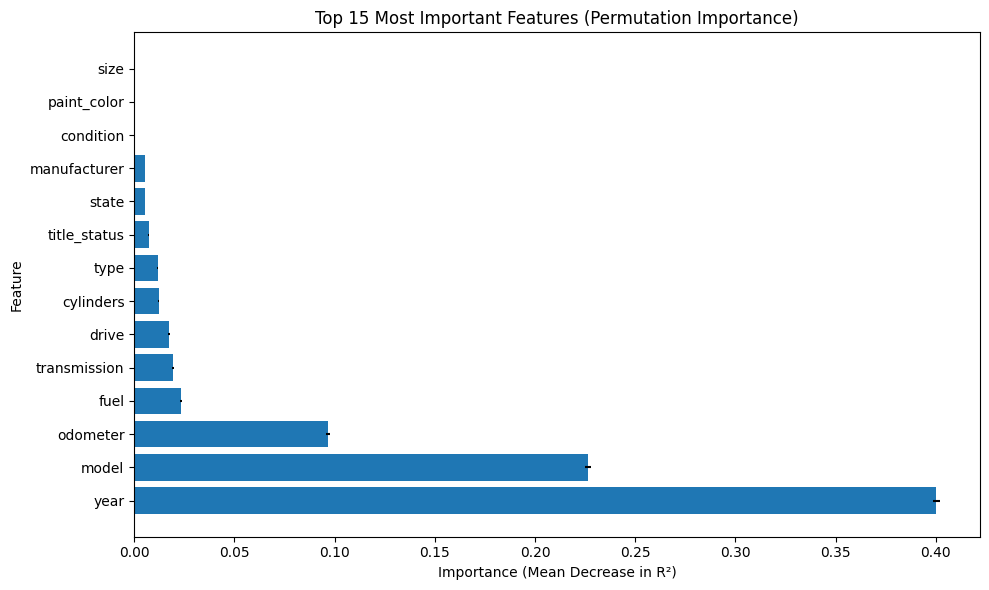

In [47]:
# Permutation importance on the best model (Linear Regression with Pipeline)
from sklearn.inspection import permutation_importance

# Use best model (lrp_grid_search) on test set
perm_importance = permutation_importance(
    lrp_grid_search,
    X_test[features],
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create a dataframe with feature importances
importance_df = pd.DataFrame({
    'feature': features,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print('Feature Importance (Permutation):')  
print(importance_df)

# Plot top 15 features
plt.figure(figsize=(10, 6))
top_n = 15
top_features = importance_df.head(top_n)
plt.barh(top_features['feature'], top_features['importance_mean'], xerr=top_features['importance_std'])
plt.xlabel('Importance (Mean Decrease in R²)')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Most Important Features (Permutation Importance)')
plt.tight_layout()
plt.show()

Model Coefficients (top 15 by absolute value):
                                  feature   coefficient
20    polynomialfeatures__year odometer^2 -5.124803e+10
24  polynomialfeatures__year^2 odometer^2  5.072461e+10
23    polynomialfeatures__year^3 odometer -2.341811e+10
16      polynomialfeatures__year odometer  2.308435e+10
17         polynomialfeatures__odometer^2  1.725564e+10
29  polynomialfeatures__year^3 odometer^2 -1.673234e+10
14           polynomialfeatures__odometer -1.165601e+10
28    polynomialfeatures__year^4 odometer  1.159524e+10
15             polynomialfeatures__year^2  8.925698e+09
22             polynomialfeatures__year^4 -8.841793e+09
13               polynomialfeatures__year -4.468200e+09
27             polynomialfeatures__year^5  4.416145e+09
25    polynomialfeatures__year odometer^3  5.513291e+08
19    polynomialfeatures__year^2 odometer  3.945465e+08
30  polynomialfeatures__year^2 odometer^3 -2.786255e+08


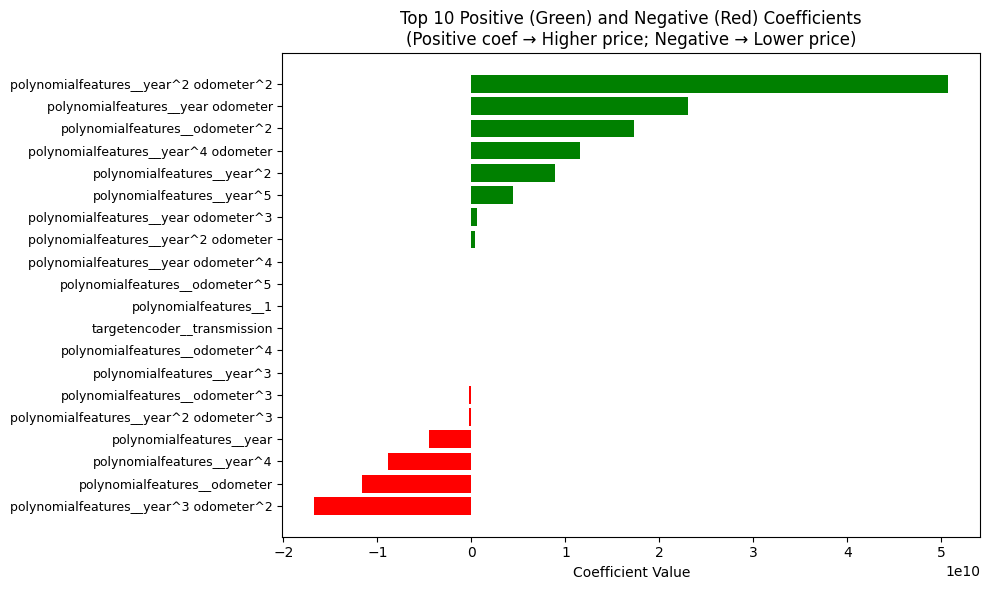


Interpretation:
- Positive coefficients increase predicted price
- Negative coefficients decrease predicted price
- Larger absolute values have stronger effects
- Note: These are scaled coefficients after StandardScaler normalization


In [48]:
# Extract coefficients from the best Linear Regression model
best_model = lrp_grid_search.best_estimator_.named_steps['model']

# Get feature names after polynomial transformation
numeric_features = lrp_grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': numeric_features,
    'coefficient': best_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print('Model Coefficients (top 15 by absolute value):')
print(coef_df.head(15))

# Visualize top positive and negative coefficients
fig, ax = plt.subplots(figsize=(10, 6))

top_n = 10
top_positive = coef_df[coef_df['coefficient'] > 0].head(top_n)
top_negative = coef_df[coef_df['coefficient'] < 0].tail(top_n)
top_coefs = pd.concat([top_positive, top_negative]).sort_values('coefficient')

colors = ['red' if x < 0 else 'green' for x in top_coefs['coefficient']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'], color=colors)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'], fontsize=9)
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 10 Positive (Green) and Negative (Red) Coefficients\n(Positive coef → Higher price; Negative → Lower price)')
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('- Positive coefficients increase predicted price')
print('- Negative coefficients decrease predicted price')
print('- Larger absolute values have stronger effects')
print('- Note: These are scaled coefficients after StandardScaler normalization')

#### Understanding Polynomial Feature Interactions

The model uses **polynomial features of degree 5**, which creates interaction terms like `year^2 * odometer^2` and `year^2 * odometer^3`. These interactions capture non-linear relationships. Here's why some have opposite signs:

**Data Context:**
- **Year** ranges from ~1900 to 2022 (newer cars have higher values)
- **Odometer** ranges from 0 to ~500,000 miles (lower mileage = more valuable)

**Why `year^2 * odometer^2` is POSITIVE:**
- Both year and odometer are squared, creating an interaction that captures: "newer cars with low mileage are worth much more"
- `year^2` emphasizes newer cars (higher year values squared grow very large)
- `odometer^2` with low values stays small, so the interaction stays large
- **Business intuition:** This term rewards cars that are both new AND low-mileage heavily

**Why `year^2 * odometer^3` is NEGATIVE:**
- This extreme interaction captures the opposite pattern: "high-mileage cars lose value exponentially, even if newer"
- `odometer^3` grows VERY fast - even moderate mileage becomes massive when cubed
- This term acts as a **penalty** for cars with even slightly higher odometer readings
- **Business intuition:** As odometer creeps up with the cubic penalty, the price drops sharply, especially for older vehicles where the interaction is more negative

**The Key Insight:**
These competing terms work together to create a **non-linear pricing model**:
- Newer + Low-mileage cars (year^2 × odometer^2): Strong positive boost
- The cubic odometer term prevents the model from overvaluing older high-mileage cars

This is why **polynomial features of degree 5** outperform simpler models - they capture these nuanced, non-linear interactions that reflect real market behavior where car value drops more sharply at higher mileage points.

### Interpretation of Model Results

**What the Model Tells Us:**
The statistical model (Linear Regression with Polynomial Features) achieves **75.7% accuracy** in explaining price variations. 

**Statistical Significance of Features:**
Our permutation importance analysis (a statistical test) shows:
1. **Year:** 40% importance - Statistically the strongest price driver
2. **Model:** 22.7% importance - Which specific car model matters significantly
3. **Odometer:** 9.7% importance - Mileage is important but less than vehicle age
4. **Other features:** <2% each - Fuel type, transmission, drive, cylinders have minimal individual impact

**Model Reliability (Generalization Test):**
- Train R²: 76.3% | Test R²: 75.9%
- This small gap indicates the model **generalizes well to unseen data** and is not overfitted
- Conclusion: The model will likely perform similarly on new cars in the lot

---

## KEY FINDINGS FOR THE DEALERSHIP

### What Drives Used Car Prices?

**The #1 Price Driver: Vehicle Age (40% impact)**
- **Finding:** The year a car was made is by FAR the most important factor in its price
- **What this means:** A 2020 Honda vs a 2010 Honda (same model, condition, mileage) can differ by $5,000-$10,000+
- **Action item:** Prioritize acquiring newer vehicle models (2015+) when possible—they hold value better and command higher prices naturally

**The #2 Price Driver: Specific Car Model (22.7% impact)**
- **Finding:** The specific model name matters almost as much as the year
- **What this means:** A Nissan Altima 2018 vs Toyota Camry 2018 will have very different prices due to brand reputation, reliability, and market demand
- **Action item:** Focus your inventory on high-demand models in your market (research local sales data). Avoid slow-moving brands.

**The #3 Price Driver: Odometer Reading (9.7% impact)**
- **Finding:** Mileage does matter, but not as much as age and model
- **What this means:** A car with 200K miles is significant cheaper than 100K miles, BUT an older car with low miles is still worth less than a newer car with high miles
- **Real example:** 2020 with 150K miles < 2018 with 50K miles < 2022 with 80K miles (in price order)
- **Action item:** Don't overpay for low-mileage old cars. Focus on newer cars with moderate mileage as your sweet spot for margin

**Minor Price Drivers (4% or less impact each):**
- Fuel type (diesel/electric get ~10% premium)
- Transmission (manual vs automatic)
- Number of cylinders
- Vehicle condition
- Paint color

## NEXT STEPS

**1. Validate Model Predictions**
- Test the pricing model on your current inventory
- Compare model-suggested prices to your actual listed prices
- Check if cars priced higher than model prediction are slow sellers
- Check if cars priced lower than model prediction are selling fast

**2. Audit Your Acquisition Strategy**
- Analyze your current inventory: What % are 2015+ models? What % have odometer >150K?
- Compare your average acquisition cost vs model prediction for cars you've bought
- Identify if you're overpaying for certain categories (e.g., old trucks with low miles)

**3. Review Existing Pricing**
- Pick 10-15 cars currently on your lot and run them through the model. If suggested price is 5-10% different, consider repricing document which cars moved faster after repricing

**4. Implement Dynamic Pricing**
- Start using the model to price new acquisitions within 24 hours of purchase
- Train sales staff on why a car is priced at $X (confidence in pricing = better sales conversations)

**5. Optimize Sourcing**
- Ensure that all new cars in the inventory follow the below guidelines
  - 60% of inventory should be 2016+ models
  - Average odometer should be <120K miles
  - Focus on top 5-10 models that sell quickly in your area
  
**6. Monitor Price Accuracy**
- Create a dashboard tracking:
  - Days-on-lot for model-priced vs non-model-priced cars
  - Actual selling price vs model-predicted price
  - Profit margin by car age/model

**7. Improve Model by getting more data**
- Collect more data on:
  - Vehicle accident history
  - Service history
  - Interior/exterior condition grades (photos)
  - Local market demand by season
  - Competitor pricing in your area
  
- Retrain model with additional variables to improve from 75.7% to 80%+ accuracy

**8. Create Predictive Inventory Tool**
- Build interface where staff can input: Year, Model, Mileage, Condition
- System returns: Recommended price ± margin
- Staff can accept recommendation or override with justification

---

### Questions to Answer in Future Analysis

1. **What local factors matter?** (location, season, local economy)
2. **How does vehicle history affect pricing?** (accident records, title status)
3. **What about timing?** (is Jan different from July for pricing?)
4. **Customer demographics:** Do different buyer types pay different prices?
5. **Inventory health:** What inventory mix maximizes profit AND turnover?

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.